# AI Driven Phishing Email Detection Using NLP

### 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

### 2. Load Dataset

In [2]:
df = pd.read_csv("../Dataset/phishing_email.csv")

In [3]:
df.head()

,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0
2,enron actuals march 30 april 1 201 estimated a...,0
3,hpl nom may 30 2001 see attached file hplno 53...,0
4,hpl nom june 1 2001 see attached file hplno 60...,0


In [4]:
df.shape

(82486, 2)

In [5]:
df.columns

Index(['text_combined', 'label'], dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 82486 entries, 0 to 82485
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   text_combined  82486 non-null  str  
 1   label          82486 non-null  int64
dtypes: int64(1), str(1)
memory usage: 1.3 MB


### 3.Data Understanding

In [7]:
df.isnull().sum()  #check missing values

text_combined    0
label            0
dtype: int64

In [8]:
df.duplicated().sum() #check duplicates values

np.int64(408)

In [9]:
df = df.drop_duplicates()   #remove duplicate values
df.shape

(82078, 2)

In [10]:
df.duplicated().sum()       #duplicate value -> 0

np.int64(0)

#### Save Outputs

In [13]:
df.to_csv("../Dataset/cleaned_phishing_email.csv", index=False)

#### Class Distribution

In [14]:
df["label"].value_counts()  
df["label"].value_counts(normalize=True) * 100

label
1    52.200346
0    47.799654
Name: proportion, dtype: float64

### 4. Exploratory Data Analysis (EDA)

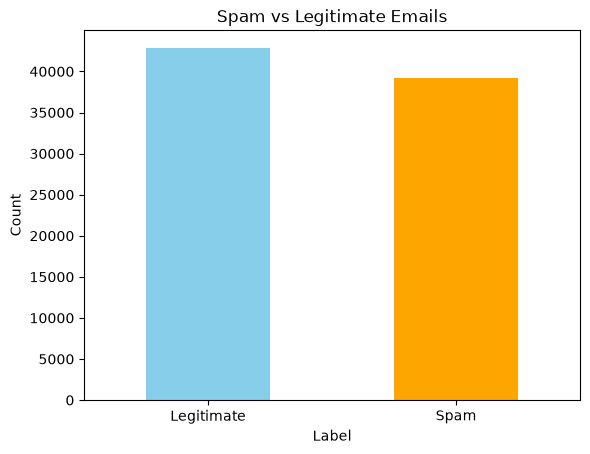

In [16]:
import matplotlib.pyplot as plt

df["label"].value_counts().plot(
    kind="bar",                    #(1) Bar charts for spam vs legitimate emails
    color=["skyblue", "orange"])
plt.title("Spam vs Legitimate Emails")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks([0,1],["Legitimate","Spam"],rotation=0)

plt.savefig("../Results/class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

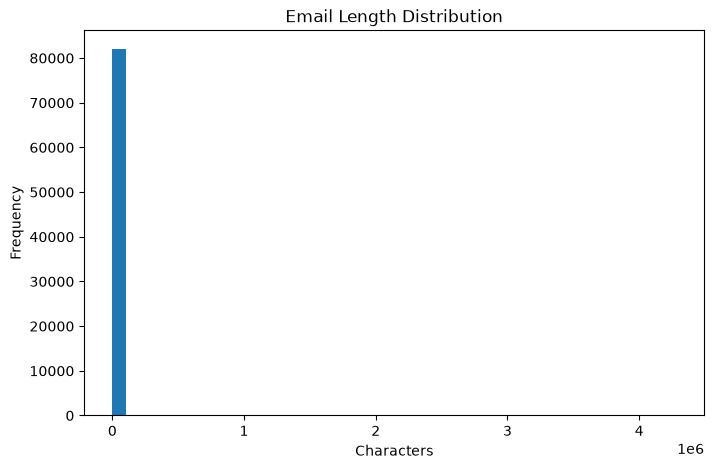

In [17]:
df["email_length"] = df["text_combined"].apply(len)
plt.figure(figsize=(8,5))

plt.hist(df["email_length"],bins=40) #(2) histogram charts for email length distribution

plt.title("Email Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Frequency")

plt.show()

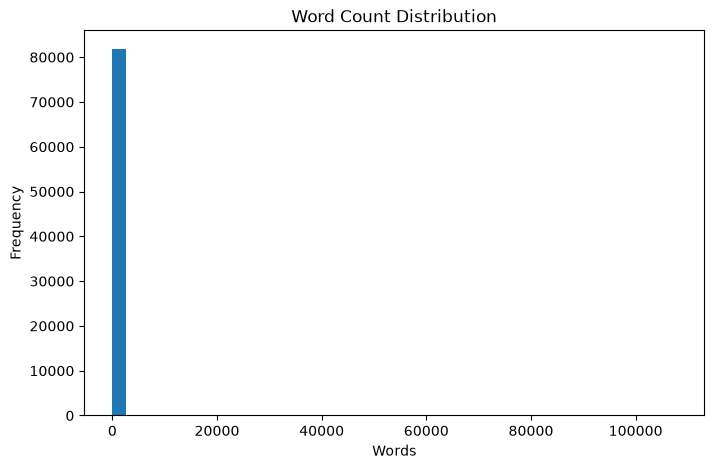

In [18]:
df["word_count"] = df["text_combined"].apply(lambda x: len(x.split()))
plt.figure(figsize=(8,5))

plt.hist(df["word_count"],bins=40)  #(3) histogram charts for word count distribution

plt.title("Word Count Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.show()

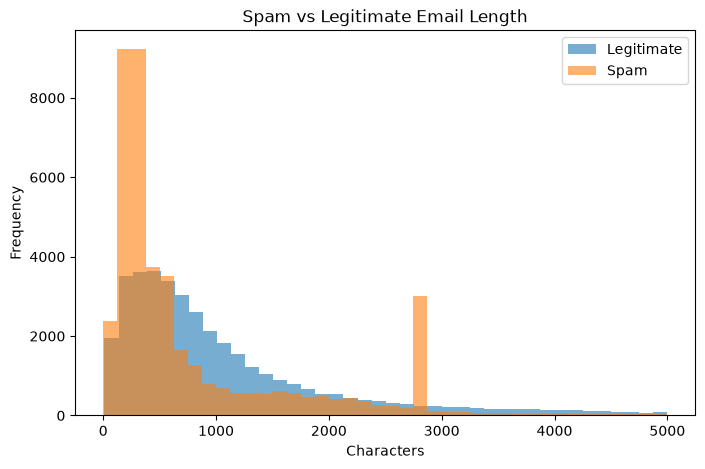

In [19]:
plt.figure(figsize=(8,5))

plt.hist(       #(4) histogram chart for Spam vs Legitimate Email Length
    df[(df["label"] == 0) & (df["email_length"] < 5000)]["email_length"],
    bins=40,
    alpha=0.6,
    label="Legitimate"
)

plt.hist(
    df[(df["label"] == 1) & (df["email_length"] < 5000)]["email_length"],
    bins=40,
    alpha=0.6,
    label="Spam"
)

plt.legend()
plt.title("Spam vs Legitimate Email Length")
plt.xlabel("Characters")
plt.ylabel("Frequency")

plt.savefig("../Results/spam_vs_legitimate_email_length.png", dpi=300, bbox_inches="tight")
plt.show()

In [20]:
df["clean_text"] = df["text_combined"]
df["clean_text"].head()

0    hpl nom may 25 2001 see attached file hplno 52...
1    nom actual vols 24 th forwarded sabrae zajac h...
2    enron actuals march 30 april 1 201 estimated a...
3    hpl nom may 30 2001 see attached file hplno 53...
4    hpl nom june 1 2001 see attached file hplno 60...
Name: clean_text, dtype: str

### 5. Data cleaning / Text cleaning 

#### 5.1 Convert Text to Lowercase

In [21]:
df["clean_text"] = df["clean_text"].str.lower()
df["clean_text"].head() 

0    hpl nom may 25 2001 see attached file hplno 52...
1    nom actual vols 24 th forwarded sabrae zajac h...
2    enron actuals march 30 april 1 201 estimated a...
3    hpl nom may 30 2001 see attached file hplno 53...
4    hpl nom june 1 2001 see attached file hplno 60...
Name: clean_text, dtype: str

#### 5.2 Remove URLs

In [22]:
import re
df["clean_text"] = df["clean_text"].apply(
    lambda text: re.sub(r"http\S+|www\S+", "", text)
)
df["clean_text"].head()

0    hpl nom may 25 2001 see attached file hplno 52...
1    nom actual vols 24 th forwarded sabrae zajac h...
2    enron actuals march 30 april 1 201 estimated a...
3    hpl nom may 30 2001 see attached file hplno 53...
4    hpl nom june 1 2001 see attached file hplno 60...
Name: clean_text, dtype: str

#### 5.3 Remove Punctuation

In [23]:
import string
df["clean_text"] = df["clean_text"].str.replace(
    "[" + string.punctuation + "]",
    "",
    regex=True
)
df["clean_text"].head()

0    hpl nom may 25 2001 see attached file hplno 52...
1    nom actual vols 24 th forwarded sabrae zajac h...
2    enron actuals march 30 april 1 201 estimated a...
3    hpl nom may 30 2001 see attached file hplno 53...
4    hpl nom june 1 2001 see attached file hplno 60...
Name: clean_text, dtype: str

#### 5.4 Remove Numbers

In [24]:
df["clean_text"] = df["clean_text"].str.replace(
    r"\d+",
    "",
    regex=True
)
df["clean_text"].head()

0    hpl nom may   see attached file hplno  xls hpl...
1    nom actual vols  th forwarded sabrae zajac hou...
2    enron actuals march  april   estimated actuals...
3    hpl nom may   see attached file hplno  xls hpl...
4    hpl nom june   see attached file hplno  xls hp...
Name: clean_text, dtype: str

#### 5.5 Remove Extra Spaces

In [25]:
df["clean_text"] = df["clean_text"].str.replace(
    r"\s+",
    " ",
    regex=True
).str.strip()
df["clean_text"].head()

0    hpl nom may see attached file hplno xls hplno xls
1    nom actual vols th forwarded sabrae zajac hou ...
2    enron actuals march april estimated actuals ma...
3    hpl nom may see attached file hplno xls hplno xls
4    hpl nom june see attached file hplno xls hplno...
Name: clean_text, dtype: str

#### 5.6 Remove HTML Tags

In [26]:
import re

df["clean_text"] = df["clean_text"].str.replace(r"<.*?>", "", regex=True)
df["clean_text"].head()

0    hpl nom may see attached file hplno xls hplno xls
1    nom actual vols th forwarded sabrae zajac hou ...
2    enron actuals march april estimated actuals ma...
3    hpl nom may see attached file hplno xls hplno xls
4    hpl nom june see attached file hplno xls hplno...
Name: clean_text, dtype: str

#### 5.7 Display Cleaned Text 

In [27]:
df["clean_text"].head(10)

0    hpl nom may see attached file hplno xls hplno xls
1    nom actual vols th forwarded sabrae zajac hou ...
2    enron actuals march april estimated actuals ma...
3    hpl nom may see attached file hplno xls hplno xls
4    hpl nom june see attached file hplno xls hplno...
5    hpl nom may see attached file hplno xls hplno xls
6    tried get fancy address came back forwarded la...
7    hpl noms february see attached file hplo xls h...
8    fw pooling contract template original message ...
9    hpl nom march see attached file hplo xls hplo xls
Name: clean_text, dtype: str

### 6. Feature Engineering

#### 1. TF-IDF Vectorization

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df["clean_text"])
y = df["label"]

In [29]:
print(X.shape)

(82078, 5000)


#### 2. Feature Matrix

In [30]:
print("Feature Matrix Shape :", X.shape)

Feature Matrix Shape : (82078, 5000)


#### 3.Target Variable

In [31]:
print("Target Shape :", y.shape)
y.head()

Target Shape : (82078,)


0    0
1    0
2    0
3    0
4    0
Name: label, dtype: int64

### 7. Train-Test Split

In [32]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (65662, 5000)
X_test  : (16416, 5000)
y_train : (65662,)
y_test  : (16416,)


### 8. Model Development

#### 8.1 Naive Bayes

In [33]:
from sklearn.naive_bayes import MultinomialNB

model_nb = MultinomialNB()

model_nb.fit(X_train, y_train)           # train model
y_pred_nb = model_nb.predict(X_test)     # make predictions

In [34]:
from sklearn.metrics import accuracy_score     #accuracy score

accuracy = accuracy_score(y_test, y_pred_nb)
print("Accuracy :", accuracy)

Accuracy : 0.9590034113060428


In [35]:
from sklearn.metrics import classification_report         #classification report
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.94      0.98      0.96      7910
           1       0.98      0.94      0.96      8506

    accuracy                           0.96     16416
   macro avg       0.96      0.96      0.96     16416
weighted avg       0.96      0.96      0.96     16416



In [36]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_nb) #confusion matrix
print(cm)

[[7742  168]
 [ 505 8001]]


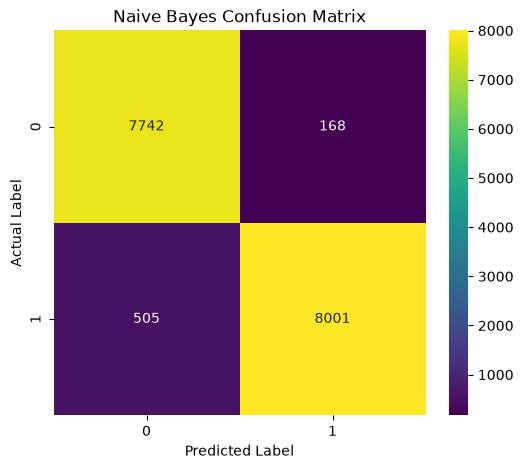

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="viridis"
)

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

#### 8.2 Logistic regression

In [38]:
from sklearn.linear_model import LogisticRegression
model_lr = LogisticRegression()

In [39]:
model_lr.fit(X_train, y_train) #train model

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [40]:
y_pred_lr = model_lr.predict(X_test) #make predictions

In [41]:
from sklearn.metrics import accuracy_score  #accuracy score

accuracy_lr = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy :", accuracy_lr)

Logistic Regression Accuracy : 0.982943469785575


In [42]:
from sklearn.metrics import classification_report #classification report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      7910
           1       0.98      0.98      0.98      8506

    accuracy                           0.98     16416
   macro avg       0.98      0.98      0.98     16416
weighted avg       0.98      0.98      0.98     16416



In [43]:
from sklearn.metrics import confusion_matrix #confusion matrix

cm_lr = confusion_matrix(y_test, y_pred_lr)
print(cm_lr)

[[7772  138]
 [ 142 8364]]


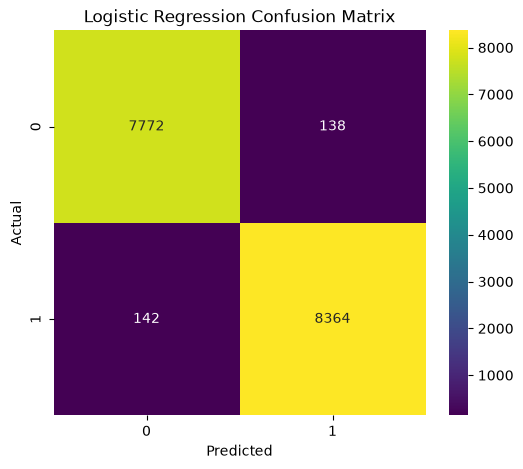

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(cm_lr,
            annot=True,
            fmt="d",
            cmap="viridis")

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("../Results/confusion_matrix_LR.png", dpi=300, bbox_inches="tight")
plt.show()

#### 8.3 Random Forest

In [45]:
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier(random_state=42)

In [46]:
model_rf.fit(X_train, y_train) #train model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [47]:
y_pred_rf = model_rf.predict(X_test) #make predictions

In [48]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy :", accuracy_rf) #accuracy score

Random Forest Accuracy : 0.9844054580896686


In [49]:
print(classification_report(y_test, y_pred_rf)) #classification report

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      7910
           1       0.99      0.98      0.98      8506

    accuracy                           0.98     16416
   macro avg       0.98      0.98      0.98     16416
weighted avg       0.98      0.98      0.98     16416



In [50]:
cm_rf = confusion_matrix(y_test, y_pred_rf) #confusion matrix
print(cm_rf) 

[[7815   95]
 [ 161 8345]]


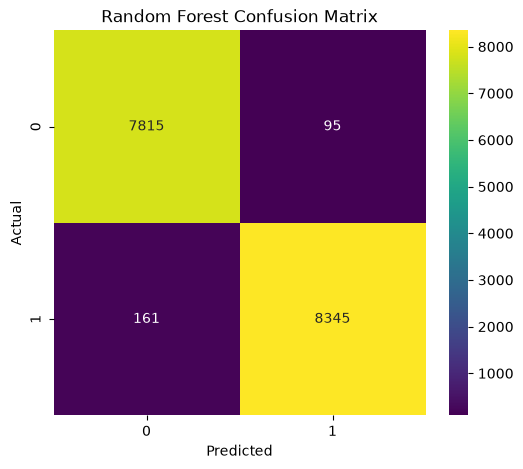

In [77]:
plt.figure(figsize=(6,5))

sns.heatmap(cm_rf,
            annot=True,
            fmt="d",
            cmap="viridis")

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("../Results/confusion_matrix_RF.png", dpi=300, bbox_inches="tight")
plt.show()

#### Feature Importance

In [52]:
print(type(X))
print(type(model_rf))
print(type(tfidf))
print(X.shape)

<class 'scipy.sparse._csr.csr_matrix'>
<class 'sklearn.ensemble._forest.RandomForestClassifier'>
<class 'sklearn.feature_extraction.text.TfidfVectorizer'>
(82078, 5000)


In [53]:
print(hasattr(tfidf, "vocabulary_"))
print(len(tfidf.get_feature_names_out()))
print(X.shape)

True
5000
(82078, 5000)


In [54]:
importance = model_rf.feature_importances_    # get importance scores

feature_names = tfidf.get_feature_names_out()     # feature names
feature_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_df = feature_df.sort_values(      # sort features
    by="Importance",
    ascending=False
)
top20 = feature_df.head(20)           # top 20
top20

,Feature,Importance
360,aug,0.035718
4960,wrote,0.031664
1475,enron,0.025418
3343,pm,0.015712
4484,thanks,0.014189
2572,list,0.013990
4319,subject,0.009234
2667,mailing,0.009121
771,click,0.008547
2874,money,0.008336


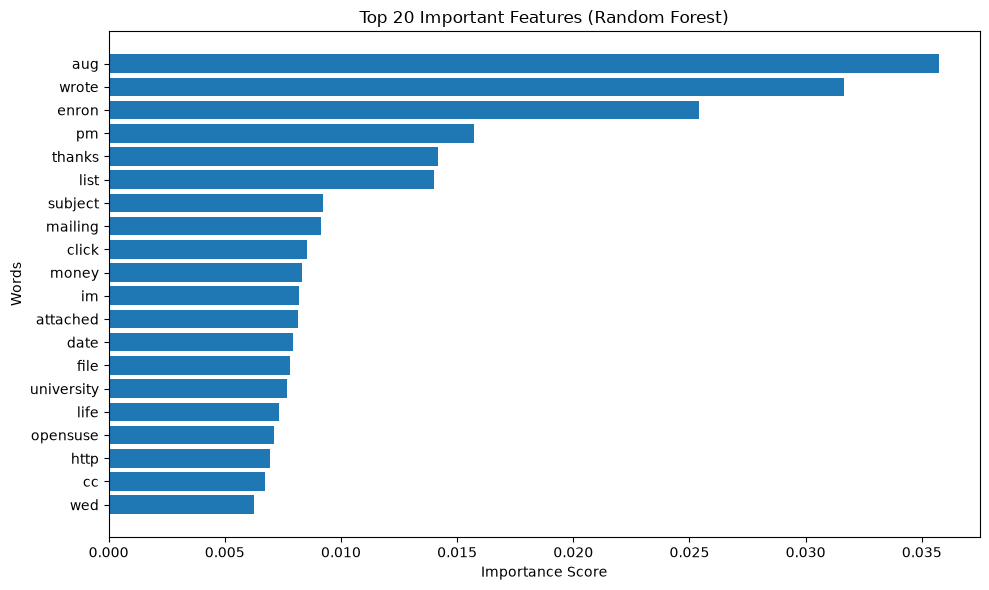

In [55]:
plt.figure(figsize=(10,6))

plt.barh(top20["Feature"], top20["Importance"])

plt.xlabel("Importance Score")
plt.ylabel("Words")
plt.title("Top 20 Important Features (Random Forest)")
plt.gca().invert_yaxis()                                # highest on top
plt.tight_layout()                                      # adjust layout
plt.savefig("../Results/feature_importance_rf.png", dpi=300) # save graph
plt.show()                                             # display graph

#### 8.4 MLP Classifier (Simple Neural Network)

In [56]:
from sklearn.neural_network import MLPClassifier

In [57]:
model_mlp = MLPClassifier(
    hidden_layer_sizes=(50,),
    max_iter=100,
    random_state=42,
    early_stopping=True
)

In [58]:
model_mlp.fit(X_train, y_train) #train model

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(50,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",100
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


In [59]:
y_pred_mlp = model_mlp.predict(X_test) #make predictions

In [60]:
accuracy_mlp = accuracy_score(y_test, y_pred_mlp) #accuracy score

print("MLP Classifier Accuracy :", accuracy_mlp)

MLP Classifier Accuracy : 0.9842836257309941


In [61]:
print(classification_report(y_test, y_pred_mlp)) #classification report

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      7910
           1       0.99      0.98      0.98      8506

    accuracy                           0.98     16416
   macro avg       0.98      0.98      0.98     16416
weighted avg       0.98      0.98      0.98     16416



In [62]:
cm_mlp = confusion_matrix(y_test, y_pred_mlp) #confusion matrix
print(cm_mlp)

[[7805  105]
 [ 153 8353]]


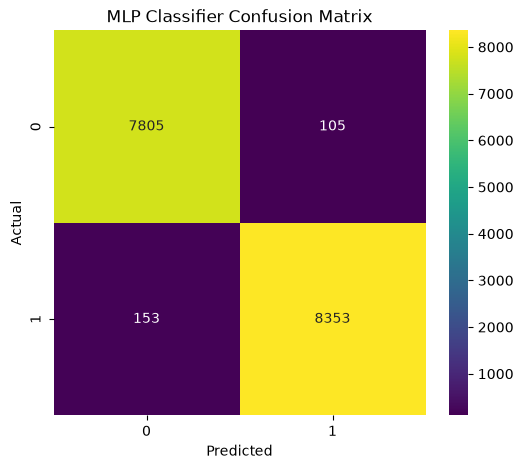

In [63]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm_mlp,
    annot=True,
    fmt="d",
    cmap="viridis"
)

plt.title("MLP Classifier Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("../Results/confusion_matrix_mlp.png", dpi=300, bbox_inches="tight")
plt.show()

### 9. Model Comparison

#### 1. Accuracy Comparison Table

In [64]:
accuracy_table = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression", "Random Forest","MLP Classifier"],
    "Accuracy": [
        accuracy,
        accuracy_lr,
        accuracy_rf,
        accuracy_mlp
    ]
})
accuracy_table

,Model,Accuracy
0,Naive Bayes,0.959003
1,Logistic Regression,0.982943
2,Random Forest,0.984405
3,MLP Classifier,0.984284


#### 2. Accuracy Comparison Graph

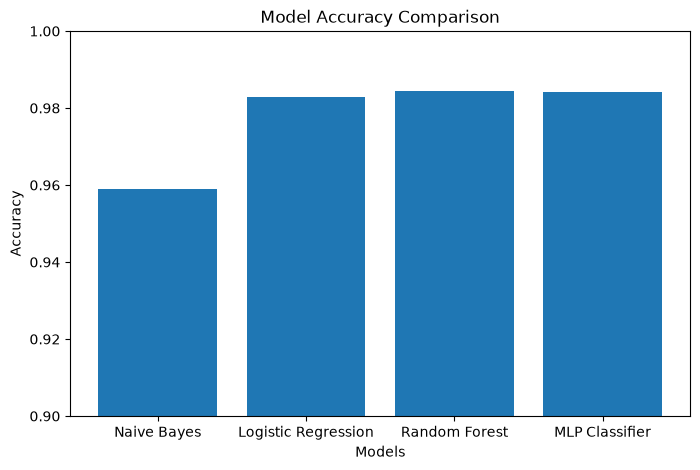

In [65]:
plt.figure(figsize=(8,5))

plt.bar(                        #campare in bar chart form
    accuracy_table["Model"],
    accuracy_table["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.ylim(0.90,1.00)

plt.savefig("../Results/model_accuracy_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

#### 3. Best Performing Model

In [66]:
best_model = accuracy_table.loc[
    accuracy_table["Accuracy"].idxmax()
]

print(best_model)

Model       Random Forest
Accuracy         0.984405
Name: 2, dtype: object


Save Outputs

In [67]:
accuracy_table.to_csv("../Results/model_accuracy.csv",index=False) #save accuracy table 

In [69]:
import joblib
joblib.dump(model_rf,"../Saved Model/best_model.pkl") #save best model 

['../Saved Model/best_model.pkl']

In [71]:
joblib.dump(tfidf,"../Saved Model/tfidf_vectorizer.pkl") # save tf-idf 

['../Saved Model/tfidf_vectorizer.pkl']

In [73]:
df.to_csv("../Dataset/final_clean_dataset.csv",index=False) # save final dataset 

In [74]:
import os

os.makedirs("../Dataset/processed", exist_ok=True)

df.to_csv("../Dataset/processed/clean_phishing_email.csv", index=False)